In [1]:
!pip install mlcroissant

In [49]:
import mlcroissant as mlc
import pandas as pd
import numpy as np
import pickle as pkl
import sklearn
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Fetch the Croissant JSON-LD
croissant_dataset = mlc.Dataset('https://www.kaggle.com/datasets/pratyushpuri/remote-work-health-impact-survey-2025/croissant/download')

# Check what record sets are in the dataset
record_sets = croissant_dataset.metadata.record_sets
print(record_sets)

# Fetch the records and put them in a DataFrame
record_set_df = pd.DataFrame(croissant_dataset.records(record_set=record_sets[0].uuid))
record_set_df.head()

  -  [Metadata(Remote Work Health Impact Survey 2025)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.
  -  [Metadata(Remote Work Health Impact Survey 2025)] Property "https://schema.org/version" is recommended, but does not exist.


[RecordSet(uuid="post_pandemic_remote_work_health_impact_2025.csv")]


,post_pandemic_remote_work_health_impact_2025.csv/Survey_Date,post_pandemic_remote_work_health_impact_2025.csv/Age,post_pandemic_remote_work_health_impact_2025.csv/Gender,post_pandemic_remote_work_health_impact_2025.csv/Region,post_pandemic_remote_work_health_impact_2025.csv/Industry,post_pandemic_remote_work_health_impact_2025.csv/Job_Role,post_pandemic_remote_work_health_impact_2025.csv/Work_Arrangement,post_pandemic_remote_work_health_impact_2025.csv/Hours_Per_Week,post_pandemic_remote_work_health_impact_2025.csv/Mental_Health_Status,post_pandemic_remote_work_health_impact_2025.csv/Burnout_Level,post_pandemic_remote_work_health_impact_2025.csv/Work_Life_Balance_Score,post_pandemic_remote_work_health_impact_2025.csv/Physical_Health_Issues,post_pandemic_remote_work_health_impact_2025.csv/Social_Isolation_Score,post_pandemic_remote_work_health_impact_2025.csv/Salary_Range
0,2025-06-01,27,b'Female',b'Asia',b'Professional Services',b'Data Analyst',b'Onsite',64,b'Stress Disorder',b'High',3,b'Shoulder Pain; Neck Pain',2,b'$40K-60K'
1,2025-06-01,37,b'Female',b'Asia',b'Professional Services',b'Data Analyst',b'Onsite',37,b'Stress Disorder',b'High',4,b'Back Pain',2,b'$80K-100K'
2,2025-06-01,32,b'Female',b'Africa',b'Education',b'Business Analyst',b'Onsite',36,b'ADHD',b'High',3,b'Shoulder Pain; Eye Strain',2,b'$80K-100K'
3,2025-06-01,40,b'Female',b'Europe',b'Education',b'Data Analyst',b'Onsite',63,b'ADHD',b'Medium',1,b'Shoulder Pain; Eye Strain',2,b'$60K-80K'
4,2025-06-01,30,b'Male',b'South America',b'Manufacturing',b'DevOps Engineer',b'Hybrid',65,None,b'Medium',5,None,4,b'$60K-80K'


In [4]:
record_set_df.columns

Index(['post_pandemic_remote_work_health_impact_2025.csv/Survey_Date',
       'post_pandemic_remote_work_health_impact_2025.csv/Age',
       'post_pandemic_remote_work_health_impact_2025.csv/Gender',
       'post_pandemic_remote_work_health_impact_2025.csv/Region',
       'post_pandemic_remote_work_health_impact_2025.csv/Industry',
       'post_pandemic_remote_work_health_impact_2025.csv/Job_Role',
       'post_pandemic_remote_work_health_impact_2025.csv/Work_Arrangement',
       'post_pandemic_remote_work_health_impact_2025.csv/Hours_Per_Week',
       'post_pandemic_remote_work_health_impact_2025.csv/Mental_Health_Status',
       'post_pandemic_remote_work_health_impact_2025.csv/Burnout_Level',
       'post_pandemic_remote_work_health_impact_2025.csv/Work_Life_Balance_Score',
       'post_pandemic_remote_work_health_impact_2025.csv/Physical_Health_Issues',
       'post_pandemic_remote_work_health_impact_2025.csv/Social_Isolation_Score',
       'post_pandemic_remote_work_health_impact_

In [5]:
clean_column_names = []
for c in record_set_df.columns:
  clean_column_names.append(c.split('/')[1])
clean_column_names

['Survey_Date',
 'Age',
 'Gender',
 'Region',
 'Industry',
 'Job_Role',
 'Work_Arrangement',
 'Hours_Per_Week',
 'Mental_Health_Status',
 'Burnout_Level',
 'Work_Life_Balance_Score',
 'Physical_Health_Issues',
 'Social_Isolation_Score',
 'Salary_Range']

In [6]:
record_set_df.columns = clean_column_names
record_set_df.head()

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,b'Female',b'Asia',b'Professional Services',b'Data Analyst',b'Onsite',64,b'Stress Disorder',b'High',3,b'Shoulder Pain; Neck Pain',2,b'$40K-60K'
1,2025-06-01,37,b'Female',b'Asia',b'Professional Services',b'Data Analyst',b'Onsite',37,b'Stress Disorder',b'High',4,b'Back Pain',2,b'$80K-100K'
2,2025-06-01,32,b'Female',b'Africa',b'Education',b'Business Analyst',b'Onsite',36,b'ADHD',b'High',3,b'Shoulder Pain; Eye Strain',2,b'$80K-100K'
3,2025-06-01,40,b'Female',b'Europe',b'Education',b'Data Analyst',b'Onsite',63,b'ADHD',b'Medium',1,b'Shoulder Pain; Eye Strain',2,b'$60K-80K'
4,2025-06-01,30,b'Male',b'South America',b'Manufacturing',b'DevOps Engineer',b'Hybrid',65,None,b'Medium',5,None,4,b'$60K-80K'


In [7]:
for c in [
    "Gender",
    "Region",
    "Industry",
    "Job_Role",
    "Work_Arrangement",
    "Mental_Health_Status",
    "Burnout_Level",
    "Physical_Health_Issues",
    "Salary_Range"
]:
  record_set_df[c] = record_set_df[c].str.decode("utf-8")

In [8]:
record_set_df.head()

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,None,Medium,5,None,4,$60K-80K


In [9]:
record_set_df['Burnout_Level'] = record_set_df['Burnout_Level'].apply(
    lambda x:
      int(x.replace('High', '3').replace('Medium', '2').replace('Low', '1'))
    if not isinstance(x, int) else x
    )
record_set_df

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,3,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,3,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,3,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,2,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,None,2,5,None,4,$60K-80K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3152,2025-06-26,62,Female,South America,Professional Services,Data Analyst,Hybrid,38,PTSD,2,4,Shoulder Pain; Neck Pain,3,$80K-100K
3153,2025-06-26,24,Female,South America,Professional Services,Software Engineer,Remote,54,None,2,4,Eye Strain,4,$100K-120K
3154,2025-06-26,45,Female,North America,Professional Services,HR Manager,Onsite,59,PTSD,2,1,Shoulder Pain,3,$40K-60K
3155,2025-06-26,38,Male,North America,Education,Operations Manager,Onsite,52,Depression,2,3,Shoulder Pain; Eye Strain; Neck Pain,5,$80K-100K


In [10]:
record_set_df.describe()

,Survey_Date,Age,Hours_Per_Week,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score
count,3157,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000
mean,2025-06-13 13:29:37.763699712,43.732024,49.904973,2.095344,2.996516,2.704783
min,2025-06-01 00:00:00,22.000000,35.000000,1.000000,1.000000,1.000000
25%,2025-06-07 00:00:00,33.000000,42.000000,2.000000,2.000000,2.000000
50%,2025-06-14 00:00:00,44.000000,50.000000,2.000000,3.000000,3.000000
75%,2025-06-20 00:00:00,55.000000,57.000000,3.000000,4.000000,4.000000
max,2025-06-26 00:00:00,65.000000,65.000000,3.000000,5.000000,5.000000
std,NaN,12.661095,8.897699,0.747260,1.163307,1.188887


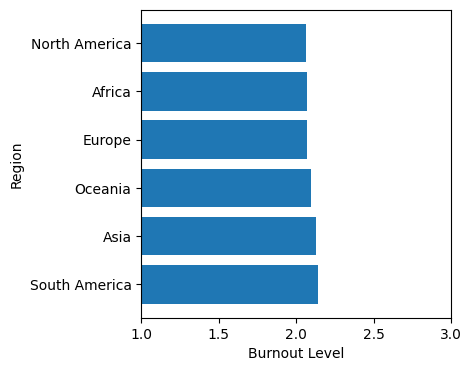

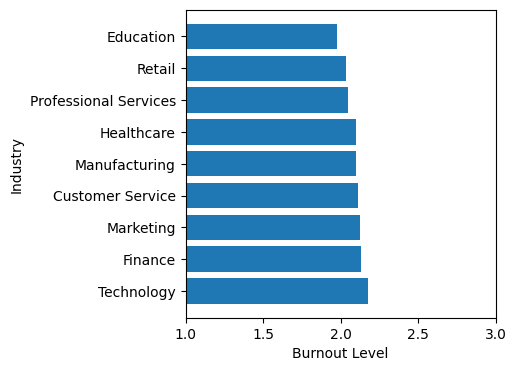

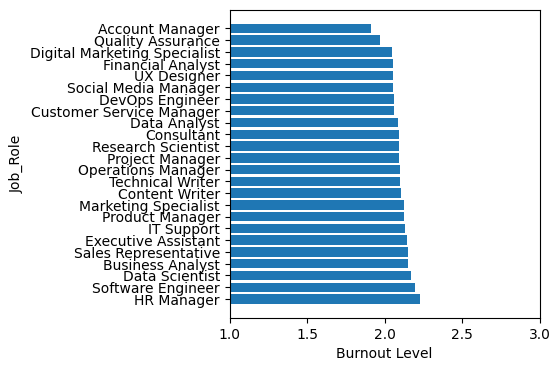

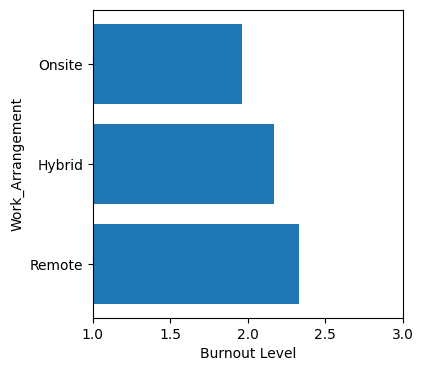

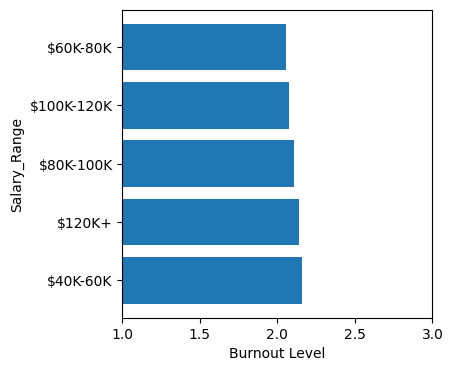

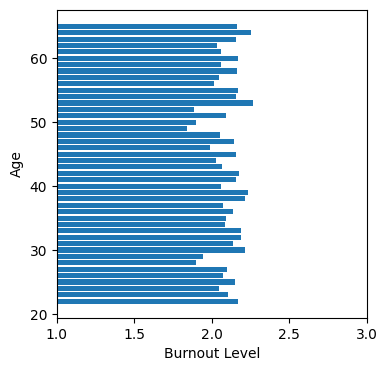

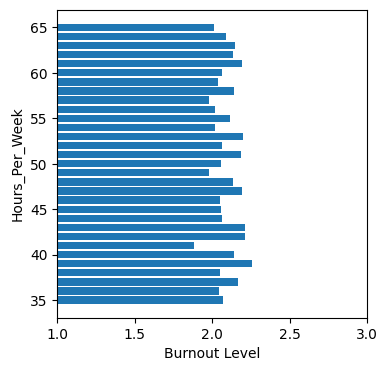

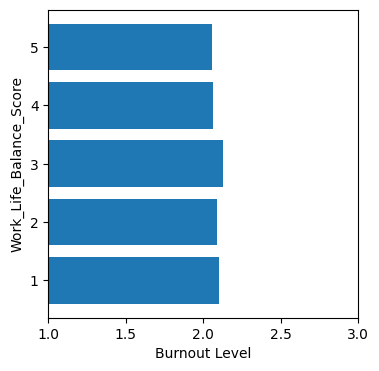

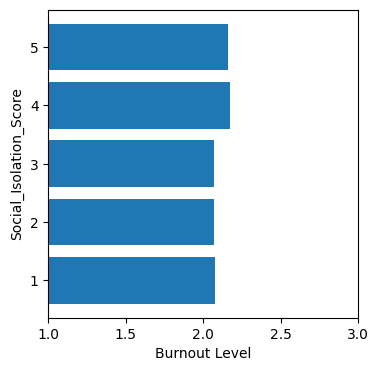

In [11]:
for c in [
    "Region",
    "Industry",
    "Job_Role",
    "Work_Arrangement",
    "Salary_Range",
    "Age",
    "Hours_Per_Week",
    "Work_Life_Balance_Score",
    "Social_Isolation_Score",
]:
  plot_data = record_set_df.groupby(c)['Burnout_Level'].mean().sort_values(ascending=False)
  plt.figure(figsize=(4, 4))
  plt.barh(y=plot_data.index, width=plot_data.values)
  plt.xlim(1,3)
  plt.xlabel('Burnout Level')
  plt.ylabel(c)
  plt.show()

In [12]:
ph_issues = [r.split('; ') for r in list(record_set_df["Physical_Health_Issues"].unique()) if r]
ph_issues

[['Shoulder Pain', 'Neck Pain'],
 ['Back Pain'],
 ['Shoulder Pain', 'Eye Strain'],
 ['Back Pain', 'Shoulder Pain'],
 ['Back Pain', 'Shoulder Pain', 'Wrist Pain'],
 ['Neck Pain'],
 ['Shoulder Pain'],
 ['Eye Strain', 'Wrist Pain'],
 ['Back Pain', 'Eye Strain'],
 ['Back Pain', 'Shoulder Pain', 'Eye Strain'],
 ['Back Pain', 'Wrist Pain'],
 ['Shoulder Pain', 'Eye Strain', 'Neck Pain', 'Wrist Pain'],
 ['Eye Strain'],
 ['Back Pain', 'Shoulder Pain', 'Eye Strain', 'Neck Pain'],
 ['Eye Strain', 'Neck Pain'],
 ['Shoulder Pain', 'Eye Strain', 'Wrist Pain'],
 ['Back Pain', 'Neck Pain'],
 ['Wrist Pain'],
 ['Back Pain', 'Shoulder Pain', 'Neck Pain'],
 ['Back Pain', 'Eye Strain', 'Neck Pain'],
 ['Back Pain', 'Shoulder Pain', 'Eye Strain', 'Wrist Pain'],
 ['Shoulder Pain', 'Eye Strain', 'Neck Pain'],
 ['Neck Pain', 'Wrist Pain'],
 ['Back Pain', 'Eye Strain', 'Neck Pain', 'Wrist Pain'],
 ['Back Pain', 'Eye Strain', 'Wrist Pain'],
 ['Back Pain', 'Neck Pain', 'Wrist Pain'],
 ['Shoulder Pain', 'Wrist Pain

In [13]:
enc = MultiLabelBinarizer()
enc.fit(ph_issues)

MultiLabelBinarizer()

In [14]:
enc.classes_

array(['Back Pain', 'Eye Strain', 'Neck Pain', 'Shoulder Pain',
       'Wrist Pain'], dtype=object)

In [15]:
ph_issues_bin = enc.transform(ph_issues)
ph_issues_bin

array([[0, 0, 1, 1, 0],
       [1, 0, 0, 0, 0],
       [0, 1, 0, 1, 0],
       [1, 0, 0, 1, 0],
       [1, 0, 0, 1, 1],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 1, 0, 0, 1],
       [1, 1, 0, 0, 0],
       [1, 1, 0, 1, 0],
       [1, 0, 0, 0, 1],
       [0, 1, 1, 1, 1],
       [0, 1, 0, 0, 0],
       [1, 1, 1, 1, 0],
       [0, 1, 1, 0, 0],
       [0, 1, 0, 1, 1],
       [1, 0, 1, 0, 0],
       [0, 0, 0, 0, 1],
       [1, 0, 1, 1, 0],
       [1, 1, 1, 0, 0],
       [1, 1, 0, 1, 1],
       [0, 1, 1, 1, 0],
       [0, 0, 1, 0, 1],
       [1, 1, 1, 0, 1],
       [1, 1, 0, 0, 1],
       [1, 0, 1, 0, 1],
       [0, 0, 0, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 0, 1, 1, 1],
       [0, 1, 1, 0, 1],
       [0, 0, 1, 1, 1]])

In [16]:
df_ph_issues = pd.DataFrame(
    enc.transform(record_set_df["Physical_Health_Issues"].apply(
        lambda x: x.split('; ') if x else '')
    ), columns=enc.classes_
)
df_ph_issues

,Back Pain,Eye Strain,Neck Pain,Shoulder Pain,Wrist Pain
0,0,0,1,1,0
1,1,0,0,0,0
2,0,1,0,1,0
3,0,1,0,1,0
4,0,0,0,0,0
...,...,...,...,...,...
3152,0,0,1,1,0
3153,0,1,0,0,0
3154,0,0,0,1,0
3155,0,1,1,1,0


In [17]:
df_drop = record_set_df.drop(columns=["Survey_Date", "Physical_Health_Issues", "Mental_Health_Status"])
df_dummies = pd.get_dummies(
    pd.concat([df_drop, df_ph_issues], axis=1),
    dtype=int
  )
df_dummies.head()

,Age,Hours_Per_Week,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score,Back Pain,Eye Strain,Neck Pain,Shoulder Pain,Wrist Pain,...,Job_Role_Technical Writer,Job_Role_UX Designer,Work_Arrangement_Hybrid,Work_Arrangement_Onsite,Work_Arrangement_Remote,Salary_Range_$100K-120K,Salary_Range_$120K+,Salary_Range_$40K-60K,Salary_Range_$60K-80K,Salary_Range_$80K-100K
0,27,64,3,3,2,0,0,1,1,0,...,0,0,0,1,0,0,0,1,0,0
1,37,37,3,4,2,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,32,36,3,3,2,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,1
3,40,63,2,1,2,0,1,0,1,0,...,0,0,0,1,0,0,0,0,1,0
4,30,65,2,5,4,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [18]:
target = ['Burnout_Level']
Y = df_dummies[target]
X = df_dummies.drop(columns=target)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [20]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
knn = KNeighborsClassifier()
tree = DecisionTreeClassifier()
nb = CategoricalNB()
svm = SVC()

In [60]:
def pipeline(model, X_train, X_test, y_train, y_test):
  scaler = MinMaxScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  model.fit(X_train_scaled, np.array(y_train).reshape(-1))
  y_pred = model.predict(X_test_scaled)
  score = f1_score(y_test, y_pred, average=None)
  accuracy = accuracy_score(y_test, y_pred)

  model_name = model.__class__.__name__

  with open(f"{model_name}_scaler.pkl", "wb") as f:
    pkl.dump(scaler, f)

  with open(f"{model_name}.pkl".replace("()", ""), "wb") as f:
    pkl.dump(model, f)

  return score, accuracy

In [61]:
for model in [knn, tree, nb, svm]:
  print(f"\n {model}")
  score, accuracy = pipeline(model, X_train, X_test, y_train, y_test)
  print(f"Score: {score}")
  print(f"Accuracy: {accuracy}")


 KNeighborsClassifier()
Score: [0.31192661 0.48829431 0.29498525]
Accuracy: 0.39082278481012656

 DecisionTreeClassifier()
Score: [0.28947368 0.42379182 0.35545024]
Accuracy: 0.3686708860759494

 CategoricalNB()
Score: [0.18965517 0.52600297 0.35097493]
Accuracy: 0.41455696202531644

 SVC()
Score: [0.         0.56537983 0.27118644]
Accuracy: 0.4224683544303797
